# ASO RNA-seq volcano plots

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text
from matplotlib.lines import Line2D

import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [6]:
RESULT_DIR = Path("/media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers")
PLOT_DIR = Path("/media/scratch/fy2306/projects/base_editing/plots/ASO")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

INPUTS = {
    "48 h": RESULT_DIR / "de_deseq2.48h.tsv",
    "72 h": RESULT_DIR / "de_deseq2.72h.tsv",
}

PADJ_THRESHOLD = 0.05
LFC_THRESHOLD = 0.0
LABELS_PER_DIRECTION = 5

COLORS = {
    "Not significant": "#B8B8B8",
    "Downregulated": "#66CCFE",
    "Upregulated": "#FF0066",
    "Threshold": mpl.colors.to_hex(mpl.colormaps["gist_earth"](0.18)),
}

HIGHLIGHT_BACKGROUND_COLORS = {
    "Not significant": "#D9D9D9",
    "Downregulated": "#C5ECFE",
    "Upregulated": "#FFB8D4",
}

HIGHLIGHT_COLORS = {
    "Not significant": "#666666",
    "Downregulated": "#0099E6",
    "Upregulated": "#D90057",
}

In [7]:
def prepare_deseq2(path):
	df = pd.read_csv(path, sep="\t")
	required = {"gene_id", "gene_name", "log2FoldChange", "padj"}
	missing = required.difference(df.columns)
	if missing:
		raise ValueError(f"Missing required columns in {path}: {sorted(missing)}")

	df = df.dropna(subset=["log2FoldChange", "padj"]).copy()
	df["neg_log10_padj"] = -np.log10(df["padj"])
	df["category"] = "Not significant"

	significant = df["padj"].lt(PADJ_THRESHOLD)
	df.loc[significant & df["log2FoldChange"].le(-LFC_THRESHOLD), "category"] = "Downregulated"
	df.loc[significant & df["log2FoldChange"].ge(LFC_THRESHOLD), "category"] = "Upregulated"
	return df


def select_labels(df, n_per_direction=5, n_extreme_lfc=3):
	labeled = []
	for category in ["Downregulated", "Upregulated"]:
		subset = (
			df.loc[(df["category"] == category) & df["gene_name"].notna()]
			.sort_values(["padj", "log2FoldChange"], ascending=[True, category == "Downregulated"])
			.drop_duplicates("gene_name")
			.head(n_per_direction)
		)
		labeled.append(subset)

	genes_with_names = df.loc[df["gene_name"].notna()]
	extreme_lfc = (
		genes_with_names.assign(abs_log2FoldChange=lambda d: d["log2FoldChange"].abs())
		.sort_values("abs_log2FoldChange", ascending=False)
		.drop_duplicates("gene_name")
		.head(n_extreme_lfc)
		.drop(columns="abs_log2FoldChange")
	)
	labeled.append(extreme_lfc)

	return pd.concat(labeled, ignore_index=True).drop_duplicates("gene_name")


def plot_volcano(path, timepoint, output_stem, labels_per_direction=5, highlight_genes=None, label_highlighted=True, label_genes=None, label_x_offset=0.35, xlim=None, ylim=None):
	df = prepare_deseq2(path)
	fig, ax = plt.subplots(figsize=(4, 4))

	df["plot_log2FoldChange"] = df["log2FoldChange"].clip(xlim[0], xlim[1]) if xlim else df["log2FoldChange"]
	df["plot_neg_log10_padj"] = df["neg_log10_padj"].clip(0, ylim[1]) if ylim else df["neg_log10_padj"]

	plot_order = ["Not significant", "Downregulated", "Upregulated"]
	sizes = {"Not significant": 1, "Downregulated": 5, "Upregulated": 5}
	alphas = {"Not significant": 0.35, "Downregulated": 0.75, "Upregulated": 0.75}
	plot_colors = COLORS if highlight_genes is None else HIGHLIGHT_BACKGROUND_COLORS

	for category in plot_order:
		subset = df.loc[df["category"] == category]
		ax.scatter(
			subset["plot_log2FoldChange"],
			subset["plot_neg_log10_padj"],
			s=sizes[category],
			c=plot_colors[category],
			alpha=alphas[category],
			edgecolors="none",
			rasterized=True,
			zorder=1 if category == "Not significant" else 2,
		)

	threshold_style = {"color": COLORS["Threshold"], "linewidth": 0.9, "linestyle": "--", "alpha": 0.8}
	ax.axhline(-np.log10(PADJ_THRESHOLD), zorder=0, **threshold_style)
	ax.axvline(-LFC_THRESHOLD, zorder=0, **threshold_style)
	ax.axvline(LFC_THRESHOLD, zorder=0, **threshold_style)

	special_highlight_df = df.iloc[0:0]

	if highlight_genes is None:
		label_df = select_labels(df, labels_per_direction).assign(display_name=lambda d: d["gene_name"])
	else:
		if not isinstance(highlight_genes, dict):
			highlight_genes = {gene: gene for gene in highlight_genes}

		highlight_df = (
			df.loc[df["gene_name"].isin(highlight_genes)]
			.drop_duplicates("gene_name")
			.assign(display_name=lambda d: d["gene_name"].map(highlight_genes))
		)
		ax.scatter(
			highlight_df["plot_log2FoldChange"],
			highlight_df["plot_neg_log10_padj"],
			s=7,
			c=[HIGHLIGHT_COLORS[category] for category in highlight_df["category"]],
			edgecolors="none",
			zorder=3,
		)
		print(highlight_df["category"].value_counts())
		print("Downregulated genes highlighted:")
		print(highlight_df[highlight_df["category"] == "Downregulated"]["gene_name"].to_list())

		missing = set(highlight_genes).difference(highlight_df["gene_name"])
		if missing:
			print(f"Genes not found in {path}: {sorted(missing)}")
		if label_genes is None:
			label_df = highlight_df if label_highlighted else highlight_df.iloc[0:0]
		else:
			label_df = highlight_df.loc[highlight_df["gene_name"].isin(label_genes)]
			special_highlight_df = label_df

	if not special_highlight_df.empty:
		ax.scatter(
			special_highlight_df["plot_log2FoldChange"],
			special_highlight_df["plot_neg_log10_padj"],
			s=7,
			c="white",
			marker="D",
			edgecolors="black",
			linewidths=0.8,
			zorder=4,
		)

	texts = []
	for row in label_df.itertuples():
		is_upregulated = row.log2FoldChange >= 0
		text_x = row.plot_log2FoldChange + (label_x_offset if is_upregulated else -label_x_offset)
		text_y = max(row.plot_neg_log10_padj, 0.5)
		texts.append(
			ax.text(
				text_x,
				text_y,
				str(row.display_name),
				fontsize=9,
				ha="left" if is_upregulated else "right",
				va="bottom",
				color="black",
				zorder=5,
			)
		)

	ax.set_ylim(bottom=0)
	adjust_text(
		texts,
		ax=ax,
		target_x=label_df["plot_log2FoldChange"].to_numpy(),
		target_y=label_df["plot_neg_log10_padj"].to_numpy(),
		expand=(1.15, 1.25),
		force_text=(0.35, 0.5),
		force_static=(0.15, 0.25),
		min_arrow_len=0,
		arrowprops={"arrowstyle": "-", "color": COLORS["Threshold"], "linewidth": 0.6},
	)

	counts = df["category"].value_counts()
	if highlight_genes is None:
		legend_handles = [
			Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=plot_colors[category],
					markeredgecolor="none", markersize=6, label=f"{category} ({counts.get(category, 0):,})")
			for category in ["Upregulated", "Downregulated", "Not significant"]
		]
	else:
		legend_handles = [
			Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=plot_colors[category],
					markeredgecolor="none", markersize=6, label=f"{category} ({counts.get(category, 0):,})")
			for category in ["Upregulated", "Downregulated"]
		]
		legend_handles += [
			Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=HIGHLIGHT_COLORS[category],
					markeredgecolor="none", markersize=6, label=f"MYC Targets\n{category} ({highlight_df['category'].value_counts().get(category, 0):,})")
			for category in ["Upregulated", "Downregulated"]
		]
	ax.legend(handles=legend_handles, frameon=False, fontsize=8, loc="upper right", handletextpad=0.3)

	if xlim is None:
		max_abs_lfc = max(abs(df["log2FoldChange"].min()), abs(df["log2FoldChange"].max()), LFC_THRESHOLD)
		x_limit = np.ceil(max_abs_lfc * 1.08)
		ax.set_xlim(-x_limit, x_limit)
	else:
		ax.set_xlim(xlim[0] - 0.1, xlim[1] + 0.1)

	if ylim is None:
		ax.set_ylim(bottom=0)
	else:
		ax.set_ylim(ylim[0], ylim[1] + 0.1)
	ax.set_xlabel(r"$\log_2$(fold change)", fontsize=12)
	ax.set_ylabel(r"$-\log_{10}$(adjusted $p$ value)", fontsize=12)
	ax.set_title(f"{timepoint}", fontsize=12)
	ax.tick_params(axis="both", labelsize=12)
	ax.spines["top"].set_visible(False)
	ax.spines["right"].set_visible(False)
	ax.grid(False)
	fig.tight_layout()

	pdf_path = PLOT_DIR / f"{output_stem}.pdf"
	fig.savefig(pdf_path, bbox_inches="tight", dpi=300, transparent=True, format="pdf")

	print(
		f"{timepoint}: {len(df):,} plotted genes; "
		f"{counts.get('Upregulated', 0):,} upregulated; "
		f"{counts.get('Downregulated', 0):,} downregulated"
	)
	
	print(f"Saved {pdf_path}")
	return fig, ax, df


def plot_volcano_highlight_genes(path, timepoint, output_stem, genes=None, label_genes=None):
	if genes is None:
		genes = ["MYC", "STING1"]
	return plot_volcano(
		path,
		timepoint=timepoint,
		output_stem=output_stem,
		highlight_genes=genes,
		label_highlighted=label_genes is not False,
		label_genes=label_genes if not isinstance(label_genes, bool) else None,
		label_x_offset=1.55,
		xlim=(-3, 5),
		ylim=(0, 12)
	)


48 h: 14,607 plotted genes; 1,377 upregulated; 1,212 downregulated
Saved /media/scratch/fy2306/projects/base_editing/plots/ASO/volcano.de_deseq2.48h.pdf
72 h: 14,492 plotted genes; 1,258 upregulated; 1,224 downregulated
Saved /media/scratch/fy2306/projects/base_editing/plots/ASO/volcano.de_deseq2.72h.pdf


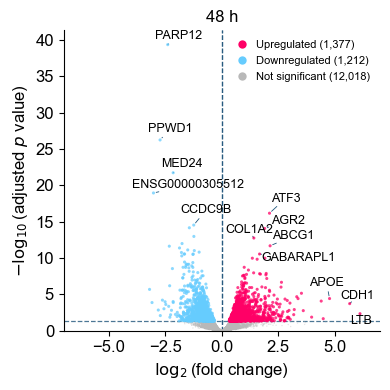

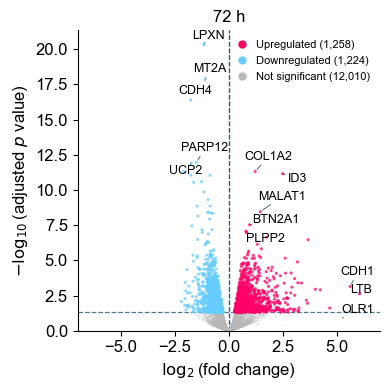

In [8]:
fig_48h, ax_48h, de_48h = plot_volcano(
    INPUTS["48 h"],
    timepoint="48 h",
    output_stem="volcano.de_deseq2.48h",
    labels_per_direction=LABELS_PER_DIRECTION,
)

fig_72h, ax_72h, de_72h = plot_volcano(
    INPUTS["72 h"],
    timepoint="72 h",
    output_stem="volcano.de_deseq2.72h",
    labels_per_direction=LABELS_PER_DIRECTION,
)

Loaded 200 HALLMARK_MYC_TARGETS_V1 genes
Highlighting 201 unique genes
category
Not significant    171
Downregulated       22
Upregulated          7
Name: count, dtype: int64
Downregulated genes highlighted:
['SNRPA', 'CAD', 'PABPC4', 'CDC45', 'APEX1', 'NOP56', 'MCM4', 'POLD2', 'ORC2', 'RPL22', 'SRM', 'GOT2', 'LSM7', 'SYNCRIP', 'CDK4', 'G3BP1', 'H2AZ1', 'CTPS1', 'RUVBL2', 'SF3B3', 'TFDP1', 'LSM2']
Genes not found in /media/scratch/fy2306/projects/base_editing/results/ASO_rnaseq_batch_2_outliers/de_deseq2.48h.tsv: ['PSMA2']
48 h: 14,607 plotted genes; 1,377 upregulated; 1,212 downregulated
Saved /media/scratch/fy2306/projects/base_editing/plots/ASO/volcano.de_deseq2.48h.highlight_myc_sting1_hallmark_myc_targets_v1.pdf
category
Not significant    170
Downregulated       26
Upregulated          4
Name: count, dtype: int64
Downregulated genes highlighted:
['SLC25A3', 'SNRPA', 'CAD', 'RPLP0', 'PABPC4', 'POLD2', 'PTGES3', 'PPM1G', 'RPL22', 'SRM', 'CDC20', 'GOT2', 'LSM7', 'YWHAQ', 'RPS2', 'G3

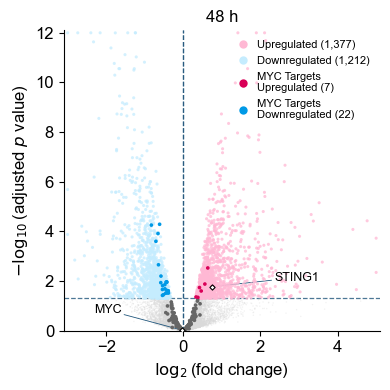

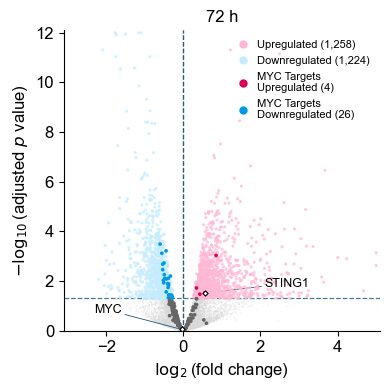

In [9]:
HALLMARK_GMT_PATH = Path("/media/scratch/fy2306/projects/base_editing/data/enrichment_analysis/h.all.v2025.1.Hs.symbols.gmt")


def load_gmt_gene_set(path, gene_set_name):
    with open(path) as gmt_file:
        for line in gmt_file:
            fields = line.rstrip("\n").split("\t")
            if fields[0] == gene_set_name:
                return fields[2:]
    raise ValueError(f"Gene set {gene_set_name!r} not found in {path}")


HALLMARK_MYC_TARGETS_V1_GENES = load_gmt_gene_set(HALLMARK_GMT_PATH, "HALLMARK_MYC_TARGETS_V1")
VOLCANO_LABEL_GENES = ["MYC", "STING1"]
HIGHLIGHT_GENE_SETS = {
    "myc_sting1_hallmark_myc_targets_v1": sorted(set(VOLCANO_LABEL_GENES) | set(HALLMARK_MYC_TARGETS_V1_GENES)),
}

print(f"Loaded {len(HALLMARK_MYC_TARGETS_V1_GENES)} HALLMARK_MYC_TARGETS_V1 genes")
print(f"Highlighting {len(HIGHLIGHT_GENE_SETS['myc_sting1_hallmark_myc_targets_v1'])} unique genes")

highlighted_volcano_plots = {}

for gene_set_name, genes in HIGHLIGHT_GENE_SETS.items():
    for timepoint, path in INPUTS.items():
        timepoint_stem = timepoint.lower().replace(" ", "")
        highlighted_volcano_plots[(gene_set_name, timepoint)] = plot_volcano_highlight_genes(
            path,
            timepoint=timepoint,
            output_stem=f"volcano.de_deseq2.{timepoint_stem}.highlight_{gene_set_name}",
            genes=genes,
            label_genes=VOLCANO_LABEL_GENES,
        )
